In [65]:
import pandas as pd
import s3fs

fs = s3fs.S3FileSystem(
    endpoint_url="https://minio.lab.sspcloud.fr",
    client_kwargs={"region_name": "us-east-1"},
)

EXTRACTION_2019 = "s3://mateomorin/legifrance/extraction_contingent/year=2019/extraction_2019.parquet"
METADATA_2019 = "s3://mateomorin/legifrance/metadata/acco_metadata_2019.parquet"

extraction = pd.read_parquet(EXTRACTION_2019, filesystem=fs)
metadata = pd.read_parquet(METADATA_2019, filesystem=fs)

In [66]:
extraction["presence_contingent_conventionnel"].mean()

np.float64(0.5638089005235603)

In [67]:
extraction["justif_contains_220"] = extraction["justification_ou_reserve"].str.contains("220")

In [68]:
extraction[~pd.col("presence_contingent_conventionnel")]["justif_contains_220"].mean()

np.float64(0.07126781695423856)

In [69]:
metadata["dateSignature"] = pd.to_datetime(metadata["dateSignature"])

DOC_PATH = "s3://mateomorin/legifrance/documents"
metadata["anneeSignature"] = metadata["dateSignature"].dt.year.astype(str).str.zfill(4)
metadata["moisSignature"] = metadata["dateSignature"].dt.month.astype(str).str.zfill(2)
metadata["docx_path"] = DOC_PATH + "/" + metadata['anneeSignature'] + "/" + metadata['moisSignature'] + "/" + metadata['cid'] + ".docx"

In [70]:
extraction = extraction.merge(metadata[["reference", "docx_path"]], how="left", on="reference")

In [71]:
extraction.info()

<class 'pandas.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   reference                          3056 non-null   str   
 1   anneeSignature                     3056 non-null   int64 
 2   presence_contingent_conventionnel  3056 non-null   bool  
 3   contingents                        3056 non-null   str   
 4   citation_exacte                    2917 non-null   str   
 5   justification_ou_reserve           2916 non-null   str   
 6   n_chunks                           3056 non-null   int64 
 7   erreur                             0 non-null      object
 8   justif_contains_220                3056 non-null   bool  
 9   docx_path                          3056 non-null   str   
dtypes: bool(2), int64(2), object(1), str(5)
memory usage: 1.7+ MB


In [72]:
contingents = extraction["contingents"].to_list()
contingents[:10]

['[{"categorie_ou_population": "l’ensemble des salariés de l’entreprise (Ouvriers, Etam et Cadres)", "nombre_heures": 360, "periode": "par an et par salarié"}]',
 '[{"categorie_ou_population": "salarié", "nombre_heures": 220, "periode": "annuel"}]',
 '[{"categorie_ou_population": "salarié", "nombre_heures": 250, "periode": "année civile"}]',
 '[{"categorie_ou_population": "salariés à temps plein", "nombre_heures": 300, "periode": "annuelle"}]',
 '[]',
 '[{"categorie_ou_population": "Salariés de l\'entreprise", "nombre_heures": 220, "periode": "Annuelle"}]',
 '[]',
 '[{"categorie_ou_population": "L\'ensemble des salariés de la société KOTI TRIBOLLET (hors cadres dirigeants)", "nombre_heures": 220, "periode": "annuel"}]',
 '[{"categorie_ou_population": "Salariés de l\'association", "nombre_heures": 110, "periode": "Annuelle"}]',
 '[{"categorie_ou_population": "salarié", "nombre_heures": 495, "periode": "année civile"}]']

In [73]:
import json
contingents = [json.loads(chaine) for chaine in contingents]

In [74]:
extraction["contingents"] = contingents

In [75]:
extraction = extraction.explode("contingents")

In [76]:
df_dict = extraction["contingents"].apply(
    lambda x: x if isinstance(x, dict) else {}
).apply(pd.Series)

extraction = pd.concat([extraction.drop(columns=["contingents"]), df_dict], axis=1)

In [77]:
extraction[extraction["reference"].duplicated(keep=False)].reset_index(drop=True).to_dict(orient="index")

{0: {'reference': 'T00619001644',
  'anneeSignature': 2019,
  'presence_contingent_conventionnel': True,
  'citation_exacte': 'Sollicite l’entreprise pour dépasser le contingent d’heures supplémentaires de 200 afin de le porter à 450 heures selon les dispositions de l’article 2.2 «heures supplémentaires» de l’accord d’entreprise relatif à l’aménagement du temps de travail signé le __________.',
  'justification_ou_reserve': "L'accord fixe un contingent d'heures supplémentaires de 200 heures (mentionné dans l'Annexe 1 et l'Article 2.2.3) et prévoit une procédure de dépassement pour le porter à 450 heures sur demande du salarié.",
  'n_chunks': 5,
  'erreur': None,
  'justif_contains_220': False,
  'docx_path': 's3://mateomorin/legifrance/documents/2019/01/ACCOTEXT000038363024.docx',
  'categorie_ou_population': 'salariés à temps plein',
  'nombre_heures': 200.0,
  'periode': 'annuelle'},
 1: {'reference': 'T00619001644',
  'anneeSignature': 2019,
  'presence_contingent_conventionnel': T

<Axes: >

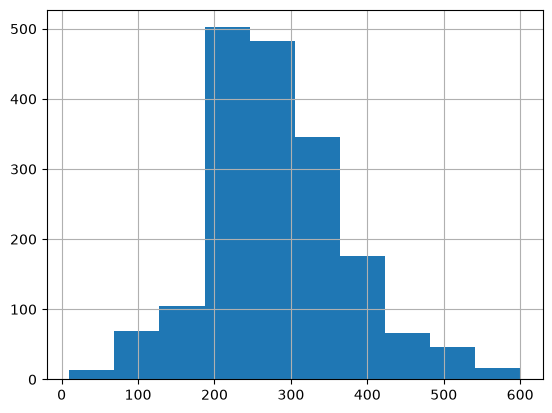

In [84]:
extraction[extraction["nombre_heures"] <= 700]["nombre_heures"].hist()

In [82]:
extraction[extraction["nombre_heures"] >= 700].to_dict(orient="index")

{323: {'reference': 'T01319006016',
  'anneeSignature': 2019,
  'presence_contingent_conventionnel': True,
  'citation_exacte': 'Le contingent annuel est fixé à 1947 heures par an et par salarié.',
  'justification_ou_reserve': "Le texte mentionne explicitement un contingent annuel de 1947 heures. Cependant, en tant qu'expert, je note que ce chiffre semble correspondre à un plafond de durée de travail annuel (type forfait) plutôt qu'à un contingent d'heures supplémentaires classique (généralement compris entre 220 et 300 heures), mais conformément à la règle de non-déduction par connaissance externe, je l'extrais tel que stipulé dans la section 'Définition du contingent annuel'.",
  'n_chunks': 5,
  'erreur': None,
  'justif_contains_220': True,
  'docx_path': 's3://mateomorin/legifrance/documents/2019/11/ACCOTEXT000041645375.docx',
  'categorie_ou_population': 'salarié',
  'nombre_heures': 1947.0,
  'periode': 'annuel'},
 483: {'reference': 'T01719001546',
  'anneeSignature': 2019,
  

In [87]:
extraction[extraction["nombre_heures"] <= 50].reset_index(drop=True).to_dict(orient="index")

{0: {'reference': 'T00619002888',
  'anneeSignature': 2019,
  'presence_contingent_conventionnel': True,
  'citation_exacte': 'La direction se réserve la possibilité de faire réaliser un quantum d’une cinquantaine d’heures supplémentaires par an, par collaborateur',
  'justification_ou_reserve': "Le texte mentionne explicitement un 'quantum' d'une cinquantaine d'heures supplémentaires par an et par collaborateur, ce qui correspond à la définition du contingent d'heures supplémentaires fixé par l'accord.",
  'n_chunks': 5,
  'erreur': None,
  'justif_contains_220': False,
  'docx_path': 's3://mateomorin/legifrance/documents/2019/12/ACCOTEXT000041718166.docx',
  'categorie_ou_population': 'par collaborateur',
  'nombre_heures': 50.0,
  'periode': 'par an'},
 1: {'reference': 'T01119000624',
  'anneeSignature': 2019,
  'presence_contingent_conventionnel': True,
  'citation_exacte': 'il est convenu de limiter le nombre des heures supplémentaires à 10 heures par mois (soit un contingent de 

In [96]:
extraction.loc[pd.col("periode").str.contains("par mois") | pd.col("periode").str.contains("mensuel"), "nombre_heures"] *= 12
extraction.loc[pd.col("periode").str.contains("par mois") | pd.col("periode").str.contains("mensuel"), "periode"] = "anuelle (montant à chaque mois x 12)"

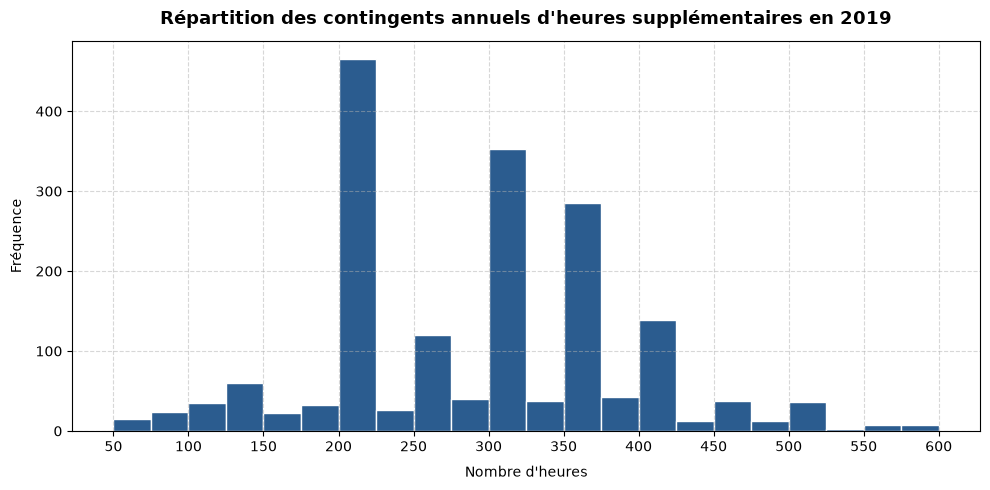

In [101]:
import matplotlib.pyplot as plt

# Définition des bornes de 50 à 600 avec un pas de 25
bins = range(50, 625, 25)

plt.figure(figsize=(10, 5))

# Filtrage entre 50 et 600 h et tracé de l'histogramme
data = extraction.query("50 <= nombre_heures <= 600")["nombre_heures"]

data.hist(
    bins=bins,
    color="#2b5c8f",
    edgecolor="white",
    grid=True,
)

plt.title("Répartition des contingents annuels d'heures supplémentaires en 2019", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Nombre d'heures", labelpad=8)
plt.ylabel("Fréquence", labelpad=8)
plt.xticks(range(50, 625, 50))  # Repères tous les 50 h pour la lisibilité
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()
plt.show()

In [50]:
for elem in contingents:
    if len(elem) > 1:
        print(elem)

[{'categorie_ou_population': 'Salariés de droit commun', 'nombre_heures': 130, 'periode': 'Annuelle'}, {'categorie_ou_population': 'Salariés de plus de 58 ans', 'nombre_heures': 90, 'periode': 'Annuelle'}, {'categorie_ou_population': 'Salariés de droit commun (autre section/accord)', 'nombre_heures': 220, 'periode': 'Annuelle'}, {'categorie_ou_population': 'Salariés de plus de 58 ans (autre section/accord)', 'nombre_heures': 90, 'periode': 'Annuelle'}]
[{'categorie_ou_population': "En cas d'annualisation (modulation)", 'nombre_heures': 175, 'periode': 'Annuel'}, {'categorie_ou_population': 'Hors modulation', 'nombre_heures': 240, 'periode': 'Annuel'}]
[{'categorie_ou_population': "personnel des secteurs d'activité suivants: fabrication, emballage/ expédition/ qualité, boucherie charcuterie", 'nombre_heures': 350, 'periode': 'année civile'}, {'categorie_ou_population': 'autres catégories de personnel', 'nombre_heures': 250, 'periode': 'année civile'}]
[{'categorie_ou_population': None, 

In [32]:
extraction.sample(10, random_state=42).to_dict(orient="index")

{361: {'reference': 'T03319004130',
  'anneeSignature': 2019,
  'presence_contingent_conventionnel': True,
  'contingents': '[{"categorie_ou_population": "entreprise", "nombre_heures": 600, "periode": "annuelle"}]',
  'citation_exacte': "les parties décident de fixer d’un commun accord le contingent annuel d’heures supplémentaires prévu à l'article L. 3121-30 du Code du travail à hauteur de 600 heures et ce, dès l’année 2019.",
  'justification_ou_reserve': "L'accord fixe explicitement un contingent d'heures supplémentaires conventionnel de 600 heures, se distinguant ainsi du contingent légal par une volonté délibérée des parties mentionnée à l'article 2.4.2.",
  'n_chunks': 5,
  'erreur': None,
  'justif_contains_220': False,
  'docx_path': 's3://mateomorin/legifrance/documents/2019/12/ACCOTEXT000041688116.docx'},
 73: {'reference': 'T02519000779',
  'anneeSignature': 2019,
  'presence_contingent_conventionnel': False,
  'contingents': '[]',
  'citation_exacte': '',
  'justification_o